# Process Raw Data

This takes the raw data in the Model/rawdata folder and splits it along the detected 'line' between images

In [1]:
from fastai.vision.all import *
from PIL import ImageFilter, Image
import numpy as np
import re
import ipyplot
import os

from ipywidgets import IntProgress
from IPython.display import display

from ipynb.fs.full.Deink_00_Utils import *

Image Size: (320, 240)
Clean: True
Batch Size: 2


# Set up util functions

In [2]:
# process a single image
def process_image(img):
    # Do the resizing
    resize_img = resize(img, split_idx=1) # Resize the image to match our training.
    
    return resize_img.convert('RGB')

In [3]:
# compile some regex for future matching

# These are for the data sets where the source has no tattoo and should be processed into a silhouette
## plain/silhouette naming pair convention 
source_re = re.compile(r'.*_source\..*') # for images without tattoos, but never had any
mask_re = re.compile(r'.*_mask\..*') # for manually created silhouettes for training
tattooless_re = re.compile(r'.*_tattooless\..*') # for evenutal tattoo image generation 

# Process the images

In [4]:
# Should we clean first?
if clean:
    print(f"Cleaning {path_sil_source}")
    for x in path_sil_source.glob("synthetic-*"):
        if x.is_file():
            os.remove(x)
    print(f"Cleaning {path_sil_mask}")
    for x in path_sil_mask.glob("synthetic-*"):
        if x.is_file():
            os.remove(x)
    print(f"Cleaning {path_sil_tattooless}")
    for x in path_sil_tattooless.glob("training-*"):
        if x.is_file():
            os.remove(x)        

Cleaning data/silhouette/source
Cleaning data/silhouette/mask
Cleaning data/silhouette/tattooless


In [5]:
# Fetch our files from the rawdata
raw_image_files = get_image_files(path_sil_rawdata)

sources = []
masks = []
tattoolesses = []

print("Processing Raw Images")
max_count = len(raw_image_files)
f = IntProgress(min=0, max=max_count, description="Raw Images: ") # instantiate the bar
display(f) # display the bar

# loop over all the images and process them
for raw_image_file in raw_image_files:
    f.value += 1 # signal to increment the progress bar
    
    # load the image and process
    #print(f"Processing {raw_image_file}")
    try:
        pil_image = PILImage.create(raw_image_file)
        resize_img = process_image(pil_image)
    except OSError:
        print(f"Could not process {raw_image_file}")
        continue
    
    # Save the file
    basename = os.path.basename(raw_image_file)
    if source_re.match(basename):
        resize_img.save(path_sil_source / re.sub(r'_source', "", basename))
        sources.append(resize_img)
    elif mask_re.match(basename):
        resize_img.save(path_sil_mask / re.sub(r'_mask', "", basename))
        masks.append(resize_img)
    elif tattooless_re.match(basename):
        resize_img.save(path_sil_tattooless / re.sub(r'_tattooless', "", basename))
        tattoolesses.append(resize_img)
    else: 
        print(f"WARNING: {raw_image_file} does not match naming convention. Skipping.")

Processing Raw Images


IntProgress(value=0, description='Raw Images: ', max=152)

Processed 30 sources


/opt/conda/lib/python3.11/site-packages/ipyplot/_utils.py:95: FutureWarning: The input object of type 'Image' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Image', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  return np.asarray(seq, dtype=type(seq[0]))



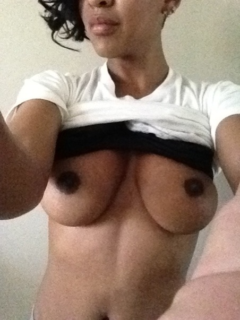
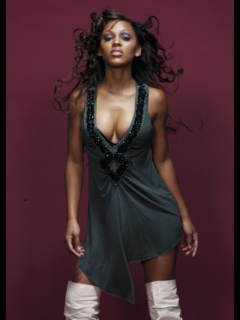
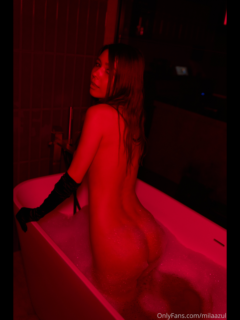
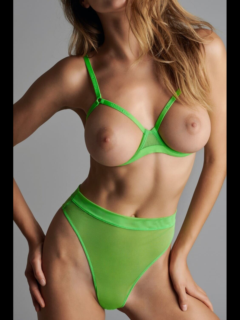
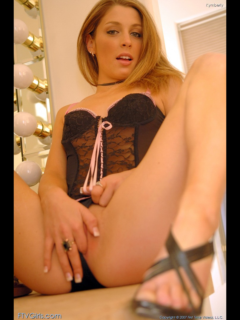


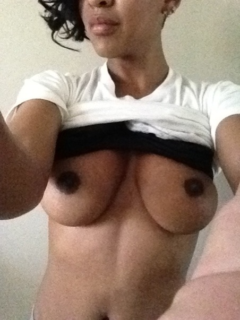
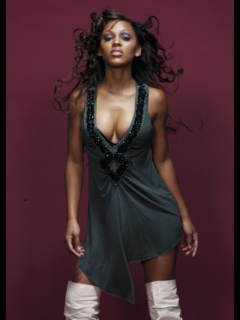
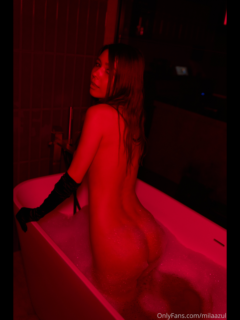
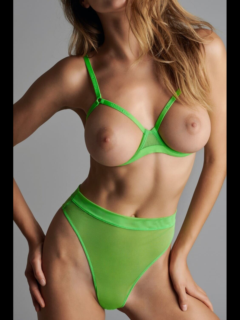
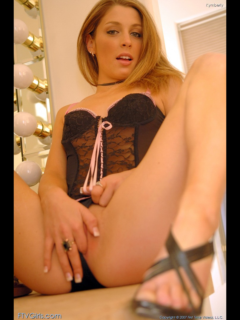

In [6]:
# print out the sources
print(f"Processed {len(sources)} sources")
ipyplot.plot_images(sources, max_images=5, img_width=150)

Processed 30 masks



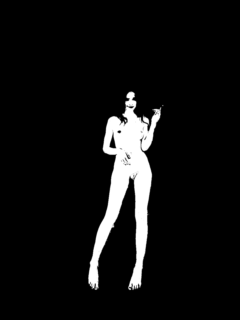
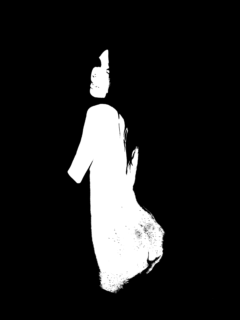
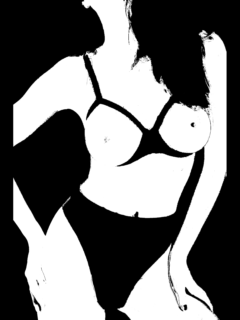
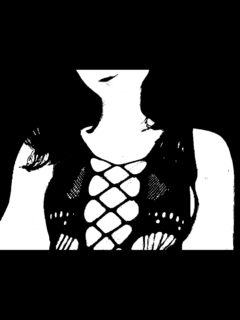
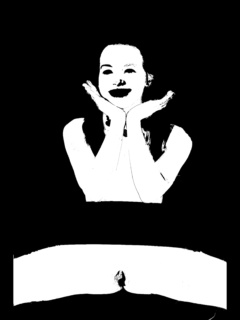


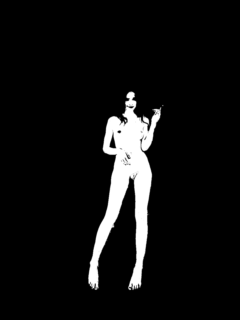
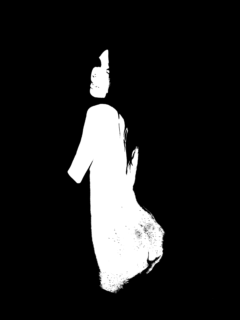
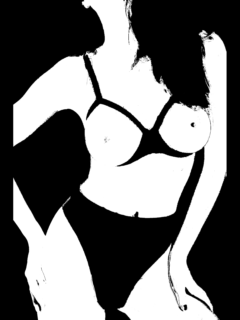
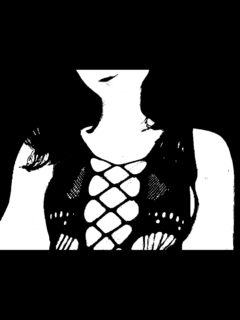
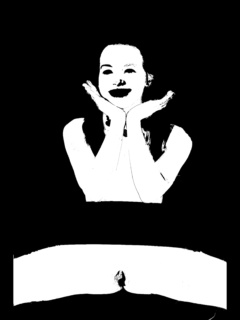

In [7]:
# print out the masks
print(f"Processed {len(masks)} masks")
ipyplot.plot_images(masks, max_images=5, img_width=150)

Processed 92 tattoolesses



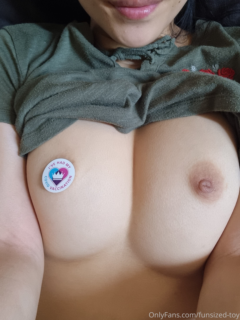
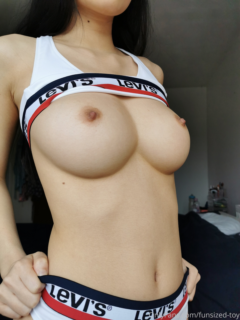
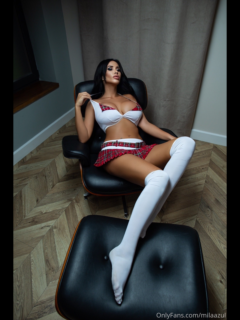
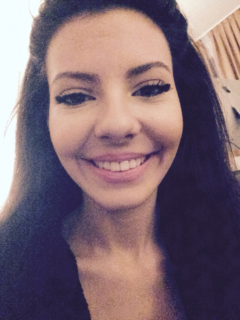
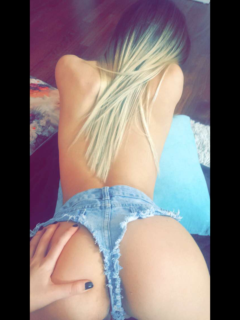


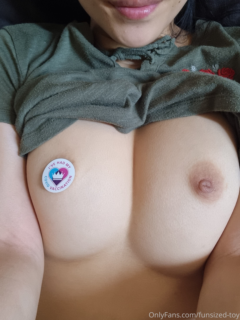
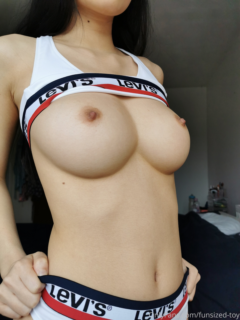
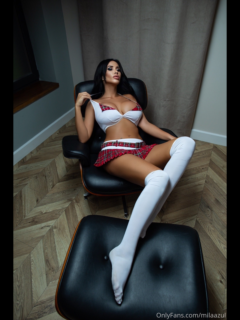
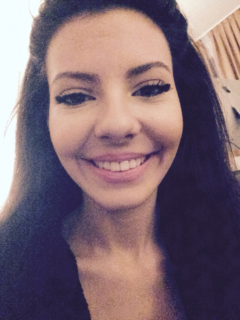
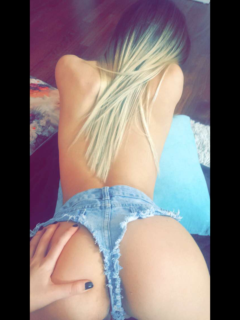

In [8]:
# print out the tattooless sources
print(f"Processed {len(tattoolesses)} tattoolesses")
ipyplot.plot_images(tattoolesses, max_images=5, img_width=150)